In [17]:
!pip install catboost

In [18]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [19]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


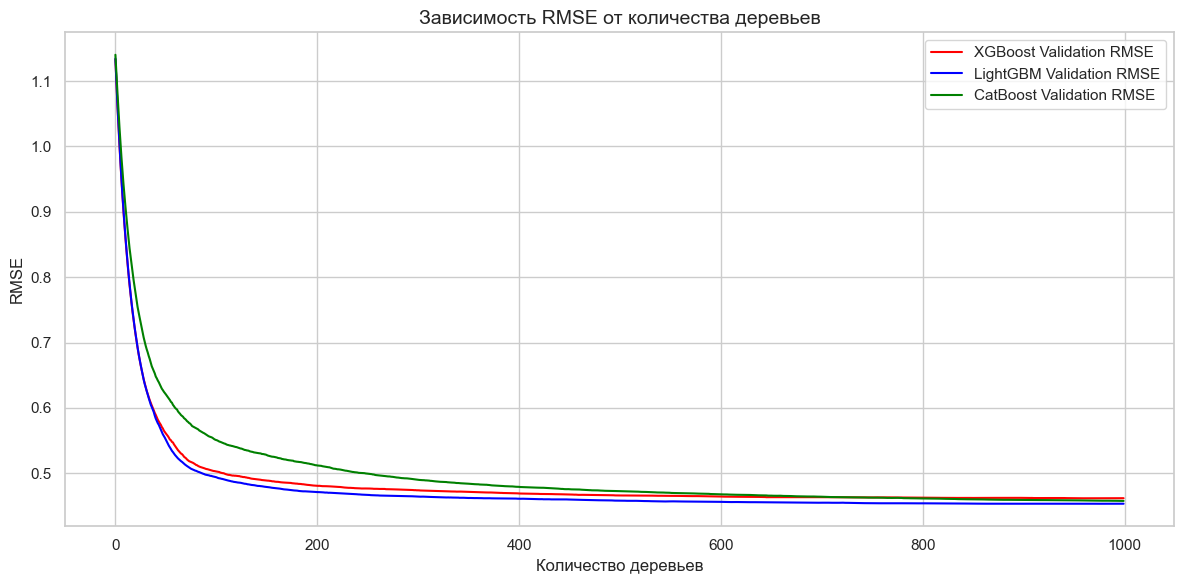

In [20]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
SELECTED_N_ESTIMATORS = 400

In [42]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder

class MyGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, 
                 subsample=1.0, colsample_bytree=1.0, categorical_features=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.categorical_features = categorical_features
        
        self.trees = []
        self.feature_indices = [] 
        self.encoder = None
        self.feature_importances_ = None

    def _prepare_data(self, X):

        if self.categorical_features is not None:
            if self.encoder is None:
                self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
                X[:, self.categorical_features] = self.encoder.fit_transform(X[:, self.categorical_features])
            else:
                X[:, self.categorical_features] = self.encoder.transform(X[:, self.categorical_features])
        return X.astype(float)

    def fit(self, X, y):
        X = self._prepare_data(X.copy())
        n_samples, n_features = X.shape
        self.trees = []
        self.feature_indices = []
        

        self.base_prediction = np.mean(y)
        current_predictions = np.full(n_samples, self.base_prediction)
        
        importances = np.zeros(n_features)

        for _ in range(self.n_estimators):

            residuals = y - current_predictions
            

            indices = np.random.choice(
                n_samples, 
                size=int(n_samples * self.subsample), 
                replace=False
            )
            

            feat_indices = np.random.choice(
                n_features, 
                size=int(n_features * self.colsample_bytree), 
                replace=False
            )
            

            X_sub = X[indices][:, feat_indices]
            y_sub = residuals[indices]
            
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X_sub, y_sub)
            

            importances[feat_indices] += tree.feature_importances_ * self.learning_rate
            

            preds = tree.predict(X[:, feat_indices])
            current_predictions += self.learning_rate * preds
            
            self.trees.append(tree)
            self.feature_indices.append(feat_indices)


        self.feature_importances_ = importances / self.n_estimators

    def predict(self, X):
        X = self._prepare_data(X.copy())
        predictions = np.full(X.shape[0], self.base_prediction)
        
        for tree, feat_indices in zip(self.trees, self.feature_indices):
            predictions += self.learning_rate * tree.predict(X[:, feat_indices])
            
        return predictions

Проверка subsample

ПРОВЕРКА ПАРАМЕТРА SUBSAMPLE

Subsample: 0.5
R2: 0.8382
Learning time: 6.428 сек
----------------------------------------

Subsample: 0.6
R2: 0.8364
Learning time: 7.674 сек
----------------------------------------

Subsample: 0.7
R2: 0.8414
Learning time: 8.963 сек
----------------------------------------

Subsample: 0.8
R2: 0.8382
Learning time: 10.341 сек
----------------------------------------

Subsample: 0.9
R2: 0.8384
Learning time: 11.722 сек
----------------------------------------

Subsample: 1.0
R2: 0.8350
Learning time: 13.028 сек
----------------------------------------



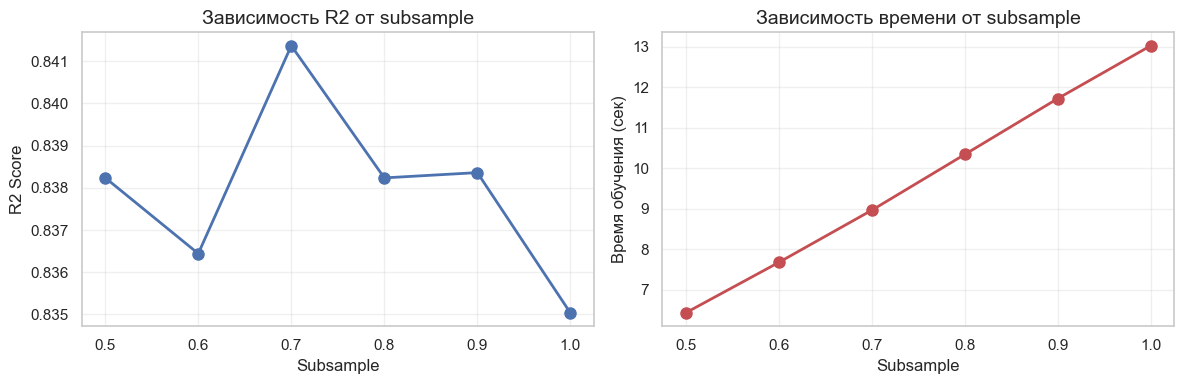


ВЫВОДЫ:
Лучший R2: 0.8414 при subsample = 0.7
Самый быстрый: 6.4 сек при subsample = 0.5


In [43]:
# ПРОВЕРКА SUBSAMPLE

import time
from sklearn.metrics import r2_score

subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_subsample = []

print("="*60)
print("ПРОВЕРКА ПАРАМЕТРА SUBSAMPLE")
print("="*60 + "\n")

for subsample_value in subsamples:
    start_time = time.time()
    model = MyBoost(subsample=subsample_value, colsample_bytree=1.0, n=400, lr=0.05, depth=7, seed=42)
    model.fit(X_train, y_train)
    learning_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    results_subsample.append({
        'subsample': subsample_value,
        'R2': r2,
        'time': learning_time
    })
    
    print(f"Subsample: {subsample_value}")
    print(f"R2: {r2:.4f}")
    print(f"Learning time: {learning_time:.3f} сек")
    print("-"*40 + "\n")

# Визуализация результатов subsample
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([r['subsample'] for r in results_subsample], [r['R2'] for r in results_subsample], 'bo-', linewidth=2, markersize=8)
plt.xlabel('Subsample', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('Зависимость R2 от subsample', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot([r['subsample'] for r in results_subsample], [r['time'] for r in results_subsample], 'ro-', linewidth=2, markersize=8)
plt.xlabel('Subsample', fontsize=12)
plt.ylabel('Время обучения (сек)', fontsize=12)
plt.title('Зависимость времени от subsample', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print(f"Лучший R2: {max(results_subsample, key=lambda x: x['R2'])['R2']:.4f} при subsample = {max(results_subsample, key=lambda x: x['R2'])['subsample']}")
print(f"Самый быстрый: {min(results_subsample, key=lambda x: x['time'])['time']:.1f} сек при subsample = {min(results_subsample, key=lambda x: x['time'])['subsample']}")

Проверка colsample_bytree

ПРОВЕРКА ПАРАМЕТРА COLSAMPLE_BYTREE

Colsample_bytree: 0.5
R2: 0.8424
Learning time: 6.801 сек
----------------------------------------

Colsample_bytree: 0.6
R2: 0.8424
Learning time: 6.799 сек
----------------------------------------

Colsample_bytree: 0.7
R2: 0.8411
Learning time: 8.525 сек
----------------------------------------

Colsample_bytree: 0.8
R2: 0.8422
Learning time: 10.084 сек
----------------------------------------

Colsample_bytree: 0.9
R2: 0.8385
Learning time: 11.714 сек
----------------------------------------

Colsample_bytree: 1.0
R2: 0.8350
Learning time: 13.386 сек
----------------------------------------



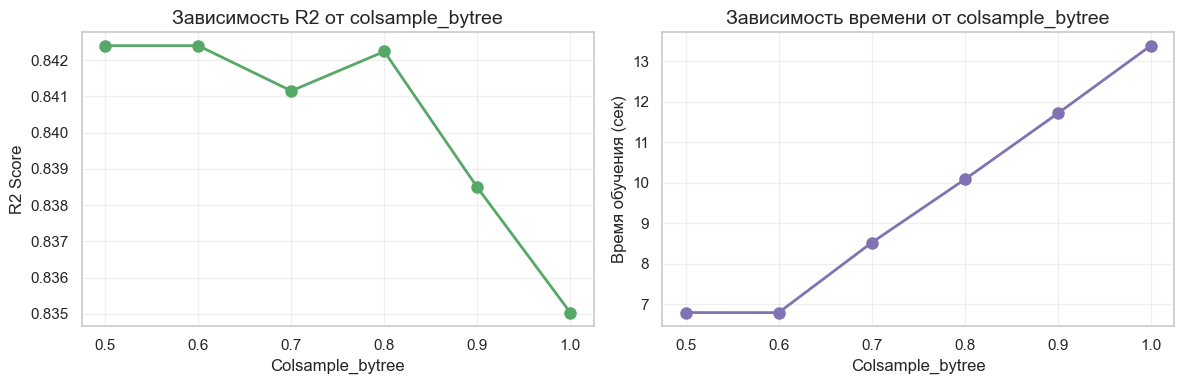


ВЫВОДЫ:
Лучший R2: 0.8424 при colsample_bytree = 0.5
Самый быстрый: 6.8 сек при colsample_bytree = 0.6


In [44]:
col_samples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_colsample = []

print("="*60)
print("ПРОВЕРКА ПАРАМЕТРА COLSAMPLE_BYTREE")
print("="*60 + "\n")

for colsample_value in col_samples:
    start_time = time.time()
    model = MyBoost(subsample=1.0, colsample_bytree=colsample_value, n=400, lr=0.05, depth=7, seed=42)
    model.fit(X_train, y_train)
    learning_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    results_colsample.append({
        'colsample_bytree': colsample_value,
        'R2': r2,
        'time': learning_time
    })
    
    print(f"Colsample_bytree: {colsample_value}")
    print(f"R2: {r2:.4f}")
    print(f"Learning time: {learning_time:.3f} сек")
    print("-"*40 + "\n")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([r['colsample_bytree'] for r in results_colsample], [r['R2'] for r in results_colsample], 'go-', linewidth=2, markersize=8)
plt.xlabel('Colsample_bytree', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('Зависимость R2 от colsample_bytree', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot([r['colsample_bytree'] for r in results_colsample], [r['time'] for r in results_colsample], 'mo-', linewidth=2, markersize=8)
plt.xlabel('Colsample_bytree', fontsize=12)
plt.ylabel('Время обучения (сек)', fontsize=12)
plt.title('Зависимость времени от colsample_bytree', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print(f"Лучший R2: {max(results_colsample, key=lambda x: x['R2'])['R2']:.4f} при colsample_bytree = {max(results_colsample, key=lambda x: x['R2'])['colsample_bytree']}")
print(f"Самый быстрый: {min(results_colsample, key=lambda x: x['time'])['time']:.1f} сек при colsample_bytree = {min(results_colsample, key=lambda x: x['time'])['colsample_bytree']}")

Проверка feature_importances_

ПРОВЕРКА FEATURE_IMPORTANCES_

Важность признаков (топ-8):
----------------------------------------
1. MedInc: 0.1715
2. Latitude: 0.1475
3. AveOccup: 0.1418
4. Longitude: 0.1403
5. AveRooms: 0.1309
6. Population: 0.1010
7. AveBedrms: 0.0974
8. HouseAge: 0.0696


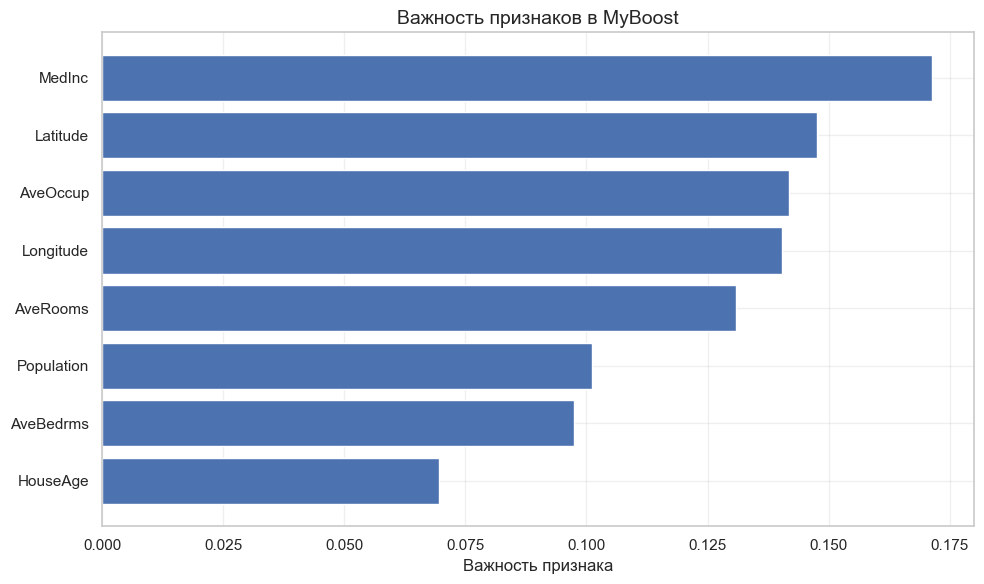

In [45]:
print("="*60)
print("ПРОВЕРКА FEATURE_IMPORTANCES_")
print("="*60 + "\n")

model = MyBoost(subsample=0.7, colsample_bytree=0.8, n=400, lr=0.05, depth=7, seed=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_names = data.feature_names

sorted_idx = np.argsort(importances)[::-1]

print("Важность признаков (топ-8):")
print("-"*40)
for i, idx in enumerate(sorted_idx):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[sorted_idx], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в MyBoost', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Полное сравнение всех конфигураций 

In [46]:
configs = [
    ("Default (sub=1.0, col=1.0)", 1.0, 1.0),
    ("Only subsample (sub=0.7, col=1.0)", 0.7, 1.0),
    ("Only colsample (sub=1.0, col=0.8)", 1.0, 0.8),
    ("Both (sub=0.7, col=0.8)", 0.7, 0.8),
]

print("="*60)
print("СРАВНЕНИЕ РАЗНЫХ КОНФИГУРАЦИЙ")
print("="*60 + "\n")

for config_name, sub_val, col_val in configs:
    start_time = time.time()
    model = MyBoost(subsample=sub_val, colsample_bytree=col_val, n=400, lr=0.05, depth=7, seed=42)
    model.fit(X_train, y_train)
    learning_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Конфигурация: {config_name}")
    print(f"Subsample={sub_val}, Colsample_bytree={col_val}")
    print(f"R2: {r2:.4f}")
    print(f"Время обучения: {learning_time:.3f} сек")
    print("-"*40 + "\n")

СРАВНЕНИЕ РАЗНЫХ КОНФИГУРАЦИЙ

Конфигурация: Default (sub=1.0, col=1.0)
Subsample=1.0, Colsample_bytree=1.0
R2: 0.8350
Время обучения: 13.535 сек
----------------------------------------

Конфигурация: Only subsample (sub=0.7, col=1.0)
Subsample=0.7, Colsample_bytree=1.0
R2: 0.8414
Время обучения: 9.287 сек
----------------------------------------

Конфигурация: Only colsample (sub=1.0, col=0.8)
Subsample=1.0, Colsample_bytree=0.8
R2: 0.8422
Время обучения: 10.172 сек
----------------------------------------

Конфигурация: Both (sub=0.7, col=0.8)
Subsample=0.7, Colsample_bytree=0.8
R2: 0.8429
Время обучения: 7.154 сек
----------------------------------------

